In [1]:
#Step 1: Importing the Libraries

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#Step 2: Setting the Display Options

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("Display options configured successfully.")

Display options configured successfully.


In [3]:
#Step 3: Setting the Random Seed

np.random.seed(42)

print("Random seed set to 42.")

Random seed set to 42.


In [4]:
#Step 4: Loading the Raw Training Data

train_path = "../data/raw/train.csv"

df = pd.read_csv(train_path)

print("Training dataset loaded successfully.")
print("Dataset shape:", df.shape)

Training dataset loaded successfully.
Dataset shape: (103904, 25)


In [5]:
#Step 5: Loading the Raw Test Data

test_path = "../data/raw/test.csv"

df_test = pd.read_csv(test_path)

print("Test dataset loaded successfully.")
print("Test dataset shape:", df_test.shape)

Test dataset loaded successfully.
Test dataset shape: (25976, 25)


In [6]:
#Step 6: Combining Train and Test Data

df_all = pd.concat(
    [df, df_test],
    ignore_index=True
)

print("Combined dataset shape:", df_all.shape)

Combined dataset shape: (129880, 25)


In [7]:
#Step 7: Checking the Dataset

print("Rows:", df_all.shape[0])
print("Columns:", df_all.shape[1])

print("\nColumn names:")
print(df_all.columns.tolist())

Rows: 129880
Columns: 25

Column names:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [8]:
#Step 8: Checking Target Distribution

target_counts = df_all["satisfaction"].value_counts()

print(target_counts)

satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64


In [9]:
#Step 9: Calculating Overall Satisfaction Rate

satisfaction_rate = (
    df_all["satisfaction"]
    .eq("satisfied")
    .mean()
    * 100
)

dissatisfaction_rate = 100 - satisfaction_rate

print(f"Satisfaction Rate    : {satisfaction_rate:.2f}%")
print(f"Dissatisfaction Rate : {dissatisfaction_rate:.2f}%")

Satisfaction Rate    : 43.45%
Dissatisfaction Rate : 56.55%


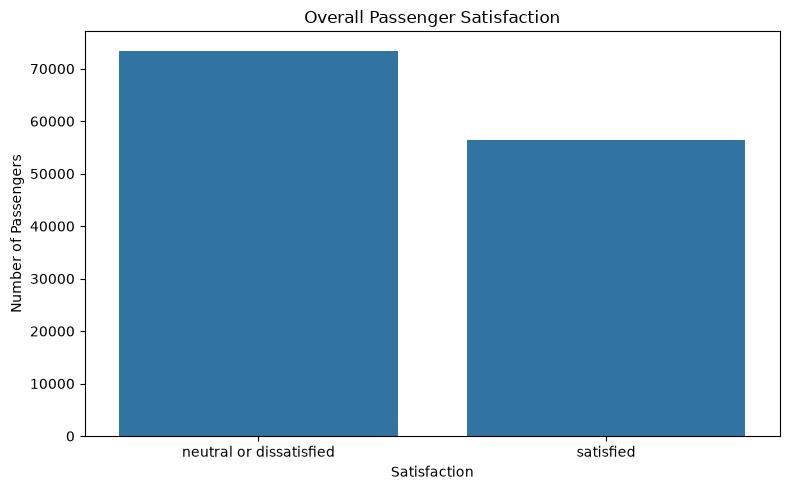

In [10]:
#Step 10: Visualizing Overall Satisfaction

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_all,
    x="satisfaction"
)

plt.title("Overall Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

In [11]:
#Step 11: Creating a Satisfaction Summary

satisfaction_summary = pd.DataFrame({
    "Metric": [
        "Total Passengers",
        "Satisfied Passengers",
        "Neutral or Dissatisfied Passengers",
        "Satisfaction Rate (%)",
        "Dissatisfaction Rate (%)"
    ],
    "Value": [
        len(df_all),
        (df_all["satisfaction"] == "satisfied").sum(),
        (df_all["satisfaction"] == "neutral or dissatisfied").sum(),
        satisfaction_rate,
        dissatisfaction_rate
    ]
})

satisfaction_summary

,Metric,Value
0,Total Passengers,129880.000
1,Satisfied Passengers,56428.000
2,Neutral or Dissatisfied Passengers,73452.000
3,Satisfaction Rate (%),43.446
4,Dissatisfaction Rate (%),56.554


In [12]:
#Step 12: Analyzing Satisfaction by Gender

gender_analysis = pd.crosstab(
    df_all["Gender"],
    df_all["satisfaction"],
    normalize="index"
) * 100

gender_analysis

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.103,42.897
Male,55.988,44.012


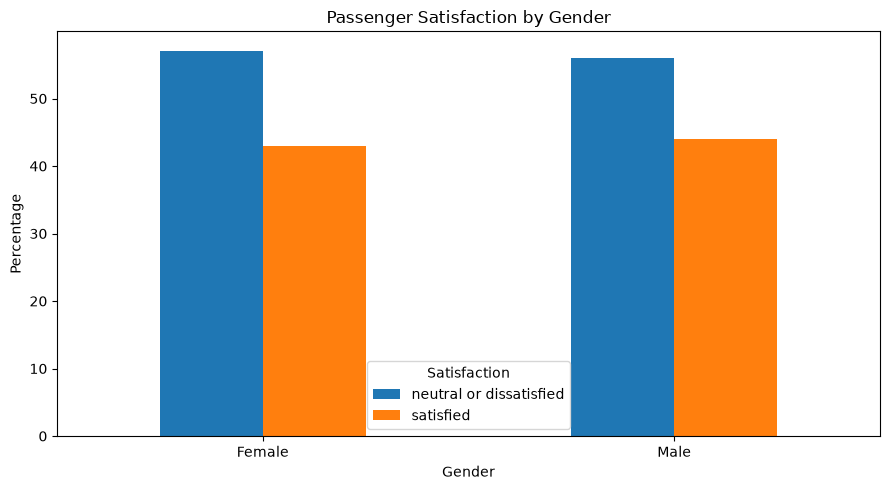

In [13]:
#Step 13: Visualizing Gender Satisfaction

gender_plot = pd.crosstab(
    df_all["Gender"],
    df_all["satisfaction"],
    normalize="index"
) * 100

gender_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Passenger Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

In [14]:
#Step 14: Analyzing Satisfaction by Customer Type

customer_type_analysis = pd.crosstab(
    df_all["Customer Type"],
    df_all["satisfaction"],
    normalize="index"
) * 100

customer_type_analysis

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.189,47.811
disloyal Customer,76.030,23.970


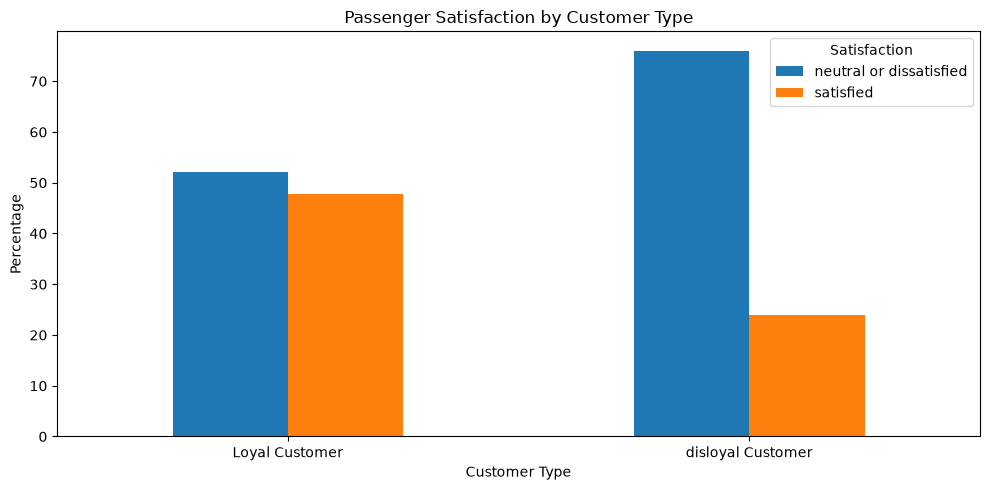

In [15]:
#Step 15: Visualizing Customer Type Satisfaction

customer_type_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Passenger Satisfaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

In [16]:
#Step 16: Analyzing Satisfaction by Travel Type

travel_analysis = pd.crosstab(
    df_all["Type of Travel"],
    df_all["satisfaction"],
    normalize="index"
) * 100

travel_analysis

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.628,58.372
Personal Travel,89.867,10.133


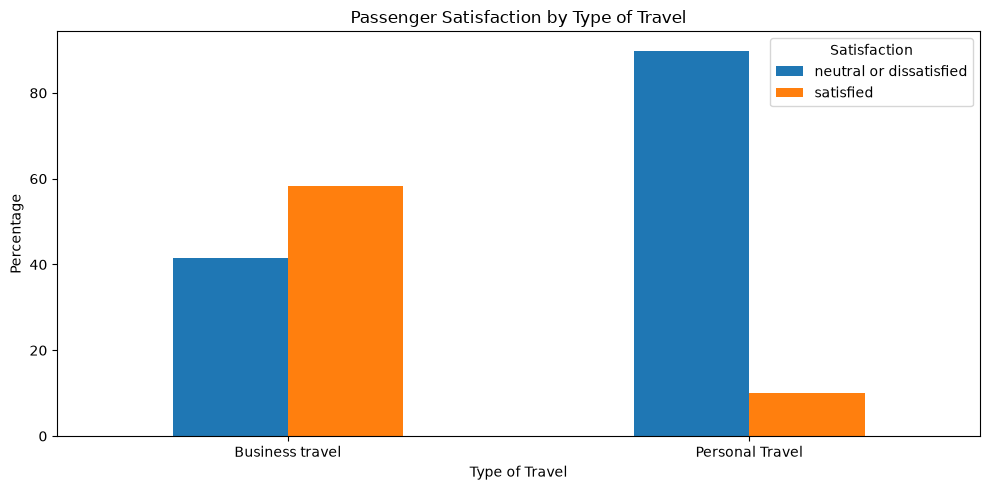

In [17]:
#Step 17: Visualizing Travel Type Satisfaction

travel_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Passenger Satisfaction by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

In [18]:
#Step 18: Analyzing Satisfaction by Class

class_analysis = pd.crosstab(
    df_all["Class"],
    df_all["satisfaction"],
    normalize="index"
) * 100

class_analysis

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.557,69.443
Eco,81.233,18.767
Eco Plus,75.359,24.641


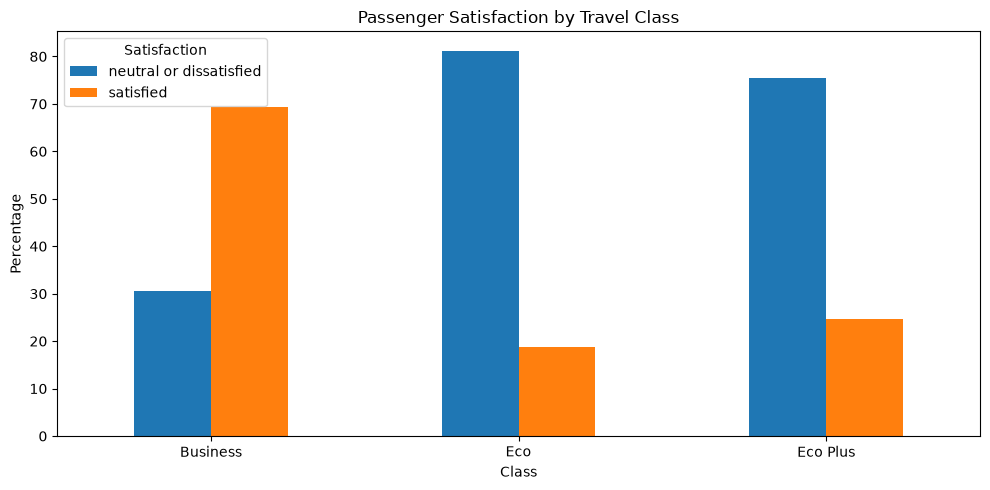

In [19]:
#Step 19: Visualizing Class Satisfaction

class_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Passenger Satisfaction by Travel Class")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

In [20]:
#Step 20: Creating Age Groups

df_all["Age Group"] = pd.cut(
    df_all["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=[
        "18 or below",
        "19-30",
        "31-45",
        "46-60",
        "61+"
    ]
)

print(df_all["Age Group"].value_counts().sort_index())

Age Group
18 or below    11070
19-30          29810
31-45          41482
46-60          37464
61+            10054
Name: count, dtype: int64


In [21]:
#Step 21: Analyzing Satisfaction by Age Group

age_analysis = pd.crosstab(
    df_all["Age Group"],
    df_all["satisfaction"],
    normalize="index"
) * 100

age_analysis

satisfaction,neutral or dissatisfied,satisfied
Age Group,,
18 or below,82.385,17.615
19-30,64.361,35.639
31-45,51.193,48.807
46-60,42.572,57.428
61+,79.182,20.818


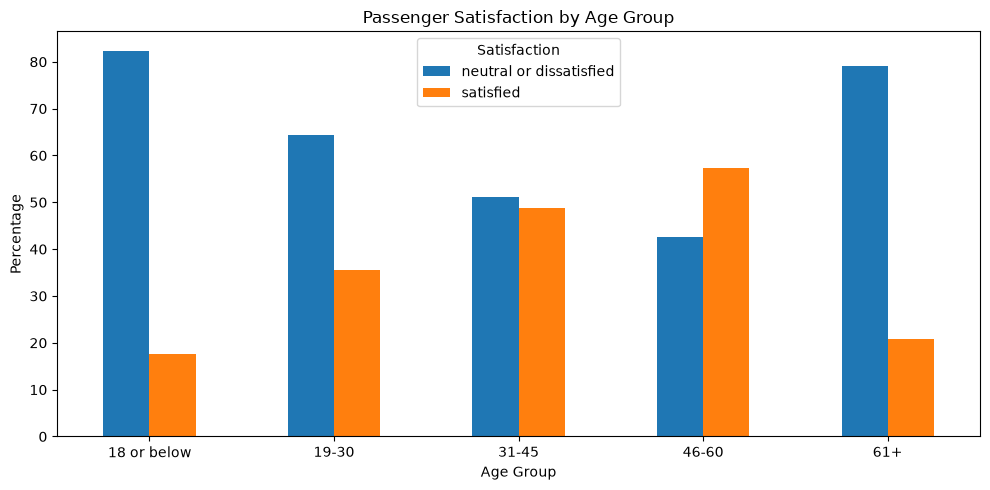

In [22]:
#Step 22: Visualizing Age Group Satisfaction

age_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Passenger Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")

plt.tight_layout()
plt.show()

In [23]:
#Step 23: Creating Service Feature List

service_features = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

print("Number of service features:", len(service_features))

Number of service features: 14


In [24]:
#Step 24: Calculating Average Service Ratings

service_ratings = (
    df_all[service_features]
    .mean()
    .sort_values(ascending=False)
)

service_ratings

Inflight service                    3.642
Baggage handling                    3.632
Seat comfort                        3.441
On-board service                    3.383
Inflight entertainment              3.358
Leg room service                    3.351
Checkin service                     3.306
Cleanliness                         3.286
Online boarding                     3.253
Food and drink                      3.205
Departure/Arrival time convenient   3.058
Gate location                       2.977
Ease of Online booking              2.757
Inflight wifi service               2.729
dtype: float64

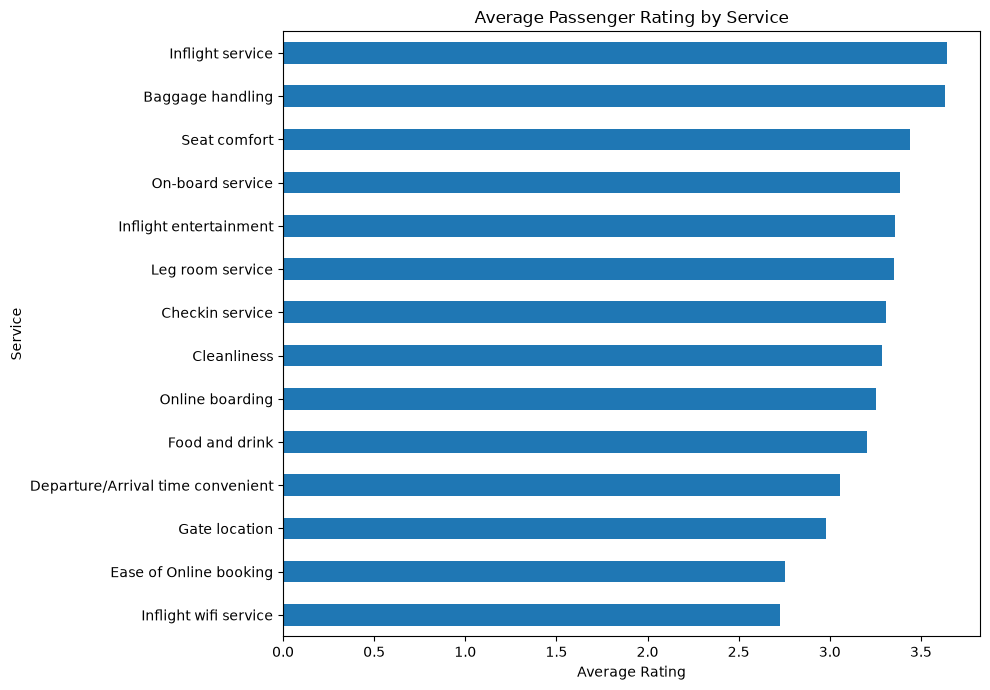

In [25]:
#Step 25: Visualizing Average Service Ratings

plt.figure(figsize=(10, 7))

service_ratings.sort_values().plot(
    kind="barh"
)

plt.title("Average Passenger Rating by Service")
plt.xlabel("Average Rating")
plt.ylabel("Service")

plt.tight_layout()
plt.show()

In [26]:
#Step 26: Calculating Satisfaction Rate by Service Rating

service_satisfaction_results = []

for feature in service_features:

    low_rating = df_all[feature] <= 2
    high_rating = df_all[feature] >= 4

    low_satisfaction = (
        df_all.loc[low_rating, "satisfaction"]
        .eq("satisfied")
        .mean()
        * 100
    )

    high_satisfaction = (
        df_all.loc[high_rating, "satisfaction"]
        .eq("satisfied")
        .mean()
        * 100
    )

    service_satisfaction_results.append({
        "Service": feature,
        "Low_Rating_Satisfaction_%": low_satisfaction,
        "High_Rating_Satisfaction_%": high_satisfaction
    })

service_analysis = pd.DataFrame(
    service_satisfaction_results
)

service_analysis

,Service,Low_Rating_Satisfaction_%,High_Rating_Satisfaction_%
0,Inflight wifi service,32.826,74.363
1,Departure/Arrival time convenient,46.844,40.549
2,Ease of Online booking,36.806,61.613
3,Gate location,48.047,45.519
4,Food and drink,31.929,53.780
5,Online boarding,15.880,72.289
6,Seat comfort,22.481,60.170
7,Inflight entertainment,18.313,62.936
8,On-board service,22.919,58.293
9,Leg room service,25.223,59.766


In [27]:
#Step 27: Calculating Satisfaction Gap

service_analysis["Satisfaction_Gap"] = (
    service_analysis["High_Rating_Satisfaction_%"]
    - service_analysis["Low_Rating_Satisfaction_%"]
)

service_analysis = service_analysis.sort_values(
    by="Satisfaction_Gap",
    ascending=False
).reset_index(drop=True)

service_analysis

,Service,Low_Rating_Satisfaction_%,High_Rating_Satisfaction_%,Satisfaction_Gap
0,Online boarding,15.880,72.289,56.410
1,Inflight entertainment,18.313,62.936,44.622
2,Inflight wifi service,32.826,74.363,41.537
3,Seat comfort,22.481,60.170,37.689
4,Cleanliness,20.545,57.044,36.499
5,On-board service,22.919,58.293,35.374
6,Leg room service,25.223,59.766,34.543
7,Checkin service,24.523,52.313,27.790
8,Ease of Online booking,36.806,61.613,24.807
9,Baggage handling,29.649,53.747,24.098


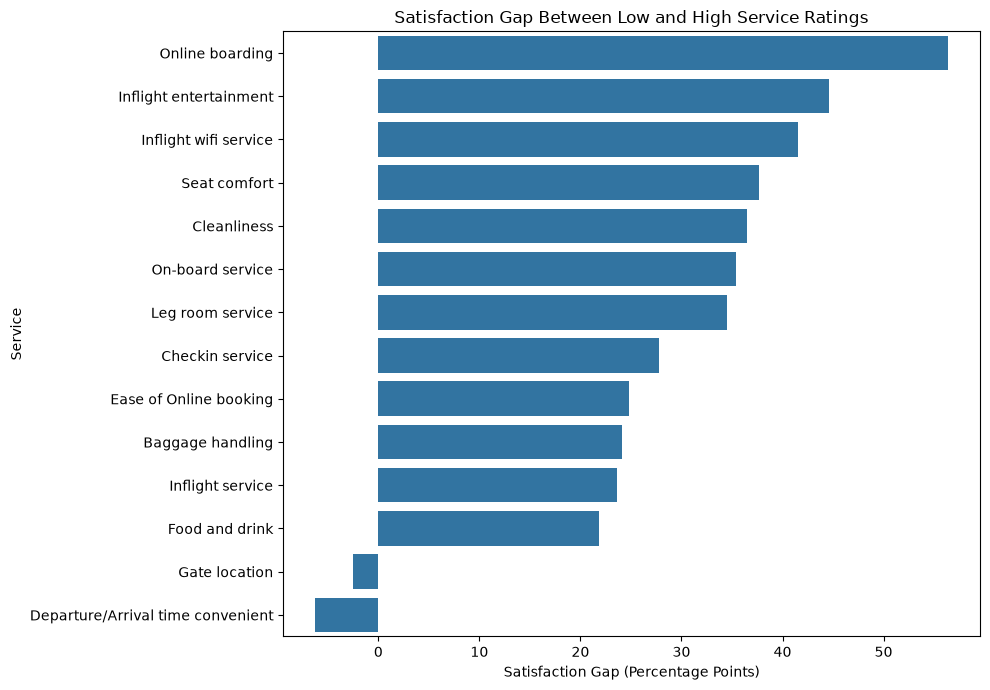

In [28]:
#Step 28: Visualizing Satisfaction Gaps

plt.figure(figsize=(10, 7))

sns.barplot(
    data=service_analysis,
    x="Satisfaction_Gap",
    y="Service"
)

plt.title("Satisfaction Gap Between Low and High Service Ratings")
plt.xlabel("Satisfaction Gap (Percentage Points)")
plt.ylabel("Service")

plt.tight_layout()
plt.show()

In [29]:
#Step 29: Analyzing Flight Distance

distance_bins = pd.cut(
    df_all["Flight Distance"],
    bins=[0, 500, 1000, 2000, 3000, 5000],
    labels=[
        "0-500",
        "501-1000",
        "1001-2000",
        "2001-3000",
        "3001+"
    ]
)

distance_analysis = (
    df_all.assign(
        Distance_Group=distance_bins
    )
    .groupby("Distance_Group", observed=True)["satisfaction"]
    .apply(
        lambda x: (x == "satisfied").mean() * 100
    )
    .reset_index(name="Satisfaction_Rate")
)

distance_analysis

,Distance_Group,Satisfaction_Rate
0,0-500,33.561
1,501-1000,32.492
2,1001-2000,46.095
3,2001-3000,64.957
4,3001+,77.349


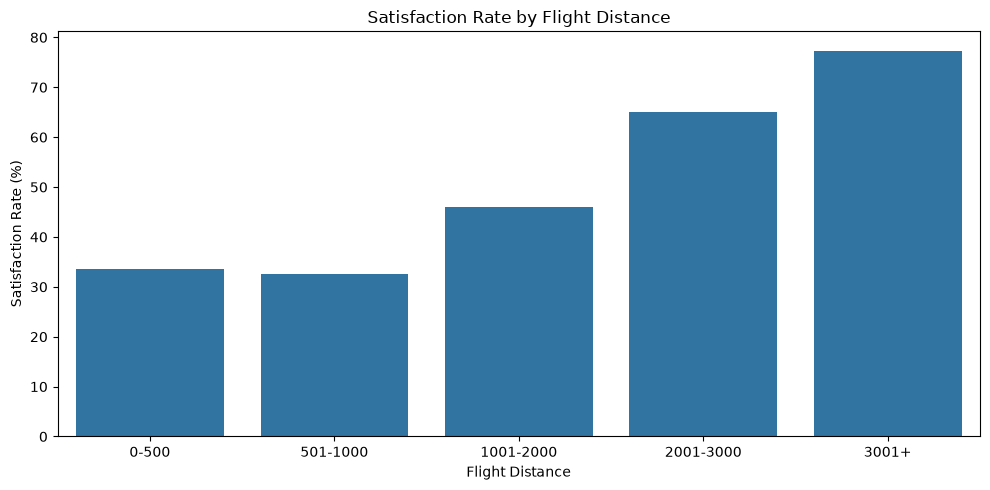

In [30]:
#Step 30: Visualizing Flight Distance Satisfaction

plt.figure(figsize=(10, 5))

sns.barplot(
    data=distance_analysis,
    x="Distance_Group",
    y="Satisfaction_Rate"
)

plt.title("Satisfaction Rate by Flight Distance")
plt.xlabel("Flight Distance")
plt.ylabel("Satisfaction Rate (%)")

plt.tight_layout()
plt.show()

In [31]:
#Step 31: Analyzing Departure Delays

delay_bins = pd.cut(
    df_all["Departure Delay in Minutes"],
    bins=[-1, 0, 15, 30, 60, np.inf],
    labels=[
        "No Delay",
        "1-15 min",
        "16-30 min",
        "31-60 min",
        "60+ min"
    ]
)

delay_analysis = (
    df_all.assign(
        Departure_Delay_Group=delay_bins
    )
    .groupby(
        "Departure_Delay_Group",
        observed=True
    )["satisfaction"]
    .apply(
        lambda x: (x == "satisfied").mean() * 100
    )
    .reset_index(name="Satisfaction_Rate")
)

delay_analysis

,Departure_Delay_Group,Satisfaction_Rate
0,No Delay,45.939
1,1-15 min,43.546
2,16-30 min,38.434
3,31-60 min,36.413
4,60+ min,35.855


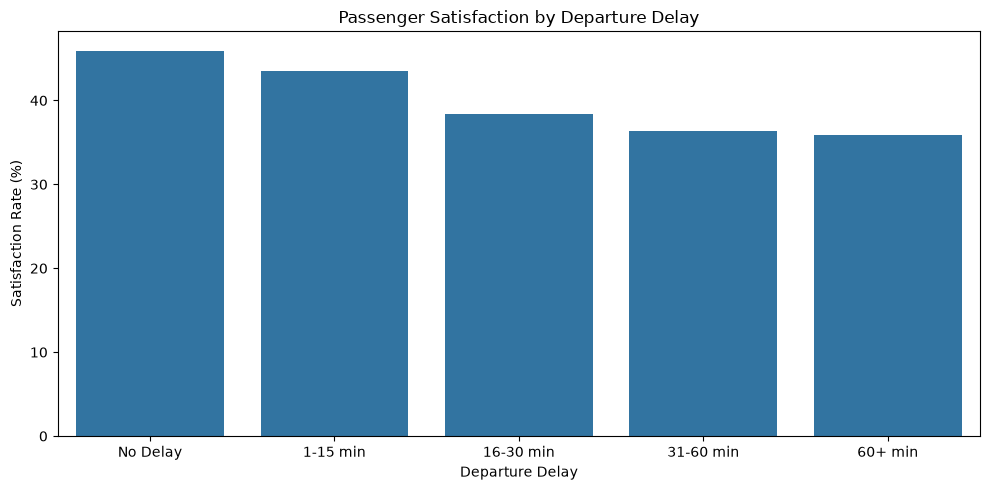

In [32]:
#Step 32: Visualizing Delay Impact

plt.figure(figsize=(10, 5))

sns.barplot(
    data=delay_analysis,
    x="Departure_Delay_Group",
    y="Satisfaction_Rate"
)

plt.title("Passenger Satisfaction by Departure Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Satisfaction Rate (%)")

plt.tight_layout()
plt.show()

In [33]:
#Step 33: Loading ANN Feature Importance

importance_path = (
    "../models/explainability/"
    "permutation_importance.csv"
)

importance_df = pd.read_csv(
    importance_path
)

importance_df = importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

print("ANN feature importance loaded successfully.")

importance_df.head(15)

ANN feature importance loaded successfully.


,Feature,Importance_Mean,Importance_STD,Positive_Importance,Cumulative_Importance,Cumulative_Percentage
0,numerical__Inflight wifi service,0.283,0.003,0.283,0.283,30.714
1,categorical__Type of Travel_Personal Travel,0.178,0.003,0.178,0.461,50.002
2,numerical__Gate location,0.112,0.003,0.112,0.573,62.097
3,categorical__Customer Type_disloyal Customer,0.099,0.004,0.099,0.672,72.841
4,numerical__Baggage handling,0.039,0.002,0.039,0.711,77.090
5,numerical__Inflight service,0.032,0.001,0.032,0.743,80.528
6,numerical__Online boarding,0.028,0.003,0.028,0.770,83.530
7,numerical__Seat comfort,0.025,0.002,0.025,0.795,86.230
8,numerical__Checkin service,0.019,0.001,0.019,0.814,88.285
9,categorical__Class_Eco,0.015,0.001,0.015,0.829,89.885


In [34]:
#Step 34: Identifying Important Original Features

print("Top 20 ANN features:\n")

for rank, feature in enumerate(
    importance_df.head(20)["Feature"],
    start=1
):
    print(f"{rank}. {feature}")

Top 20 ANN features:

1. numerical__Inflight wifi service
2. categorical__Type of Travel_Personal Travel
3. numerical__Gate location
4. categorical__Customer Type_disloyal Customer
5. numerical__Baggage handling
6. numerical__Inflight service
7. numerical__Online boarding
8. numerical__Seat comfort
9. numerical__Checkin service
10. categorical__Class_Eco
11. categorical__Customer Type_Loyal Customer
12. numerical__Ease of Online booking
13. numerical__Inflight entertainment
14. categorical__Gender_Male
15. categorical__Type of Travel_Business travel
16. categorical__Gender_Female
17. categorical__Class_Business
18. numerical__Cleanliness
19. numerical__Age
20. categorical__Class_Eco Plus


In [35]:
#Step 35: Selecting Positive ANN Feature Importance

priority_features = (
    importance_df[
        importance_df["Importance_Mean"] > 0
    ]
    .head(15)
    .copy()
)

priority_features

,Feature,Importance_Mean,Importance_STD,Positive_Importance,Cumulative_Importance,Cumulative_Percentage
0,numerical__Inflight wifi service,0.283,0.003,0.283,0.283,30.714
1,categorical__Type of Travel_Personal Travel,0.178,0.003,0.178,0.461,50.002
2,numerical__Gate location,0.112,0.003,0.112,0.573,62.097
3,categorical__Customer Type_disloyal Customer,0.099,0.004,0.099,0.672,72.841
4,numerical__Baggage handling,0.039,0.002,0.039,0.711,77.090
5,numerical__Inflight service,0.032,0.001,0.032,0.743,80.528
6,numerical__Online boarding,0.028,0.003,0.028,0.770,83.530
7,numerical__Seat comfort,0.025,0.002,0.025,0.795,86.230
8,numerical__Checkin service,0.019,0.001,0.019,0.814,88.285
9,categorical__Class_Eco,0.015,0.001,0.015,0.829,89.885


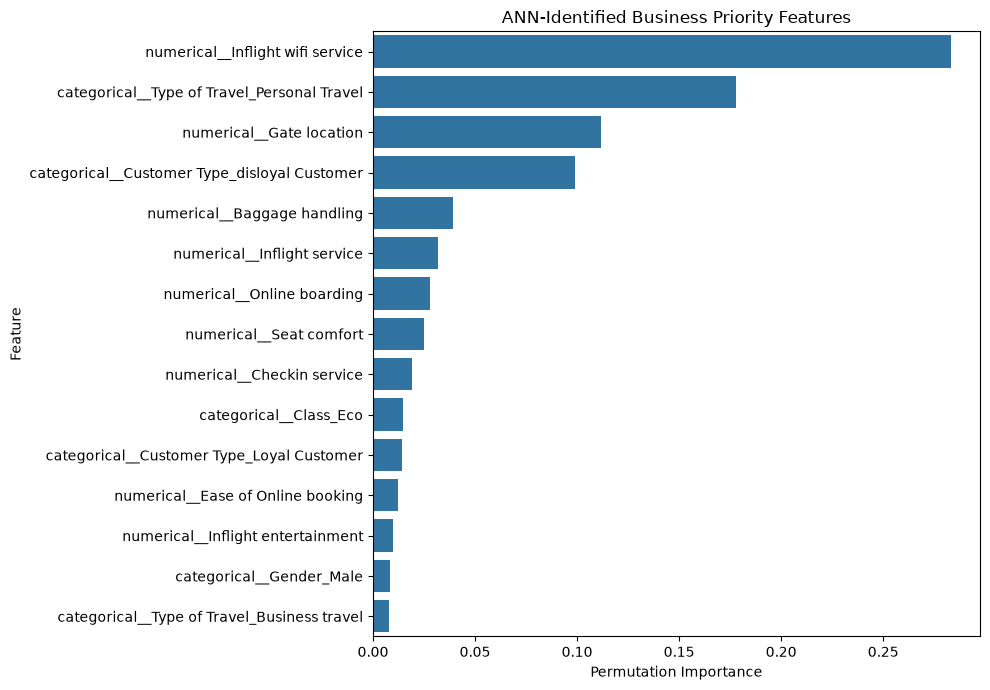

In [36]:
#Step 36: Visualizing ANN Business Priorities

plt.figure(figsize=(10, 7))

sns.barplot(
    data=priority_features,
    x="Importance_Mean",
    y="Feature"
)

plt.title("ANN-Identified Business Priority Features")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [37]:
#Step 37: Creating a Service Priority Table

service_importance = importance_df[
    importance_df["Feature"].isin(service_features)
].copy()

service_importance = service_importance.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

service_importance

,Feature,Importance_Mean,Importance_STD,Positive_Importance,Cumulative_Importance,Cumulative_Percentage


In [38]:
#Step 38: Comparing Service Importance and Service Ratings

service_business_analysis = service_importance.merge(
    service_ratings.rename("Average_Rating"),
    left_on="Feature",
    right_index=True,
    how="left"
)

service_business_analysis = service_business_analysis[
    [
        "Feature",
        "Importance_Mean",
        "Importance_STD",
        "Average_Rating"
    ]
]

service_business_analysis

,Feature,Importance_Mean,Importance_STD,Average_Rating


In [39]:
#Step 39: Identifying Improvement Opportunities

if not service_business_analysis.empty:

    importance_median = (
        service_business_analysis["Importance_Mean"]
        .median()
    )

    rating_median = (
        service_business_analysis["Average_Rating"]
        .median()
    )

    service_business_analysis["Priority"] = np.where(
        (
            service_business_analysis["Importance_Mean"]
            >= importance_median
        )
        &
        (
            service_business_analysis["Average_Rating"]
            <= rating_median
        ),
        "High Priority",
        "Monitor"
    )

else:

    service_business_analysis["Priority"] = "Monitor"

service_business_analysis

,Feature,Importance_Mean,Importance_STD,Average_Rating,Priority


In [40]:
#Step 40: Creating Business Recommendations

recommendations = []

for _, row in service_business_analysis.iterrows():

    feature = row["Feature"]
    priority = row["Priority"]

    if priority == "High Priority":

        recommendation = (
            f"Prioritize improvement of {feature} because it "
            f"is relatively important to the ANN and has a "
            f"relatively lower average passenger rating."
        )

    else:

        recommendation = (
            f"Continue monitoring {feature} and maintain its "
            f"current service performance."
        )

    recommendations.append({
        "Feature": feature,
        "Priority": priority,
        "Recommendation": recommendation
    })

business_recommendations = pd.DataFrame(
    recommendations
)

business_recommendations

""


In [41]:
#Step 41: Creating Customer Segment Summary

segment_results = []

segment_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "Age Group"
]

for column in segment_columns:

    segment_data = (
        df_all.groupby(
            column,
            observed=True
        )["satisfaction"]
        .apply(
            lambda x: (x == "satisfied").mean() * 100
        )
        .reset_index(
            name="Satisfaction_Rate"
        )
    )

    segment_data["Segment_Type"] = column

    segment_data = segment_data.rename(
        columns={
            column: "Segment"
        }
    )

    segment_results.append(
        segment_data[
            [
                "Segment_Type",
                "Segment",
                "Satisfaction_Rate"
            ]
        ]
    )

segment_satisfaction = pd.concat(
    segment_results,
    ignore_index=True
)

segment_satisfaction

,Segment_Type,Segment,Satisfaction_Rate
0,Gender,Female,42.897
1,Gender,Male,44.012
2,Customer Type,Loyal Customer,47.811
3,Customer Type,disloyal Customer,23.970
4,Type of Travel,Business travel,58.372
5,Type of Travel,Personal Travel,10.133
6,Class,Business,69.443
7,Class,Eco,18.767
8,Class,Eco Plus,24.641
9,Age Group,18 or below,17.615


In [42]:
#Step 42: Finding the Lowest-Satisfaction Segments

lowest_segments = (
    segment_satisfaction
    .sort_values(
        by="Satisfaction_Rate"
    )
    .head(10)
)

lowest_segments

,Segment_Type,Segment,Satisfaction_Rate
5,Type of Travel,Personal Travel,10.133
9,Age Group,18 or below,17.615
7,Class,Eco,18.767
13,Age Group,61+,20.818
3,Customer Type,disloyal Customer,23.970
8,Class,Eco Plus,24.641
10,Age Group,19-30,35.639
0,Gender,Female,42.897
1,Gender,Male,44.012
2,Customer Type,Loyal Customer,47.811


In [43]:
#Step 43: Finding the Highest-Satisfaction Segments

highest_segments = (
    segment_satisfaction
    .sort_values(
        by="Satisfaction_Rate",
        ascending=False
    )
    .head(10)
)

highest_segments

,Segment_Type,Segment,Satisfaction_Rate
6,Class,Business,69.443
4,Type of Travel,Business travel,58.372
12,Age Group,46-60,57.428
11,Age Group,31-45,48.807
2,Customer Type,Loyal Customer,47.811
1,Gender,Male,44.012
0,Gender,Female,42.897
10,Age Group,19-30,35.639
8,Class,Eco Plus,24.641
3,Customer Type,disloyal Customer,23.970


In [44]:
#Step 44: Creating a Business Insight Summary

business_insights_summary = pd.DataFrame({
    "Metric": [
        "Total Passengers",
        "Overall Satisfaction Rate (%)",
        "Overall Dissatisfaction Rate (%)",
        "Number of Service Features",
        "Number of ANN Features",
        "Highest Satisfaction Segment",
        "Lowest Satisfaction Segment"
    ],
    "Value": [
        len(df_all),
        satisfaction_rate,
        dissatisfaction_rate,
        len(service_features),
        len(importance_df),
        (
            highest_segments.iloc[0]["Segment_Type"]
            + " - "
            + str(highest_segments.iloc[0]["Segment"])
        ),
        (
            lowest_segments.iloc[0]["Segment_Type"]
            + " - "
            + str(lowest_segments.iloc[0]["Segment"])
        )
    ]
})

business_insights_summary

,Metric,Value
0,Total Passengers,129880
1,Overall Satisfaction Rate (%),43.446
2,Overall Dissatisfaction Rate (%),56.554
3,Number of Service Features,14
4,Number of ANN Features,27
5,Highest Satisfaction Segment,Class - Business
6,Lowest Satisfaction Segment,Type of Travel - Personal Travel


In [45]:
#Step 45: Creating the Output Folder

output_dir = "../models/business_insights"

os.makedirs(
    output_dir,
    exist_ok=True
)

print(
    "Output folder ready:",
    output_dir
)

Output folder ready: ../models/business_insights


In [46]:
#Step 46: Saving Business Insight Summary

business_insights_summary.to_csv(
    f"{output_dir}/business_insights_summary.csv",
    index=False
)

print("Business insight summary saved.")

Business insight summary saved.


In [47]:
#Step 47: Saving Segment Satisfaction

segment_satisfaction.to_csv(
    f"{output_dir}/segment_satisfaction.csv",
    index=False
)

print("Segment satisfaction analysis saved.")

Segment satisfaction analysis saved.


In [48]:
#Step 48: Saving Service Analysis

service_business_analysis.to_csv(
    f"{output_dir}/service_analysis.csv",
    index=False
)

print("Service analysis saved.")

Service analysis saved.


In [49]:
#Step 49: Saving Priority Features

priority_features.to_csv(
    f"{output_dir}/priority_features.csv",
    index=False
)

print("Priority features saved.")

Priority features saved.


In [50]:
#Step 50: Saving Business Recommendations

business_recommendations.to_csv(
    f"{output_dir}/business_recommendations.csv",
    index=False
)

print("Business recommendations saved.")

Business recommendations saved.


In [51]:
#Step 51: Verifying Saved Files

expected_files = [
    "business_insights_summary.csv",
    "segment_satisfaction.csv",
    "service_analysis.csv",
    "priority_features.csv",
    "business_recommendations.csv"
]

print("Saved files:\n")

for file_name in expected_files:

    file_path = os.path.join(
        output_dir,
        file_name
    )

    print(
        f"{file_name}:",
        "✓ Found"
        if os.path.exists(file_path)
        else "✗ Missing"
    )

Saved files:

business_insights_summary.csv: ✓ Found
segment_satisfaction.csv: ✓ Found
service_analysis.csv: ✓ Found
priority_features.csv: ✓ Found
business_recommendations.csv: ✓ Found


In [52]:
#Step 52: Creating the Final Business Report

print("=" * 70)
print("AIRLINE PASSENGER SATISFACTION — BUSINESS INSIGHTS")
print("=" * 70)

print(f"\nTotal Passengers Analyzed : {len(df_all):,}")

print(
    f"Overall Satisfaction Rate : "
    f"{satisfaction_rate:.2f}%"
)

print(
    f"Overall Dissatisfaction Rate : "
    f"{dissatisfaction_rate:.2f}%"
)

print("\nTop ANN Priority Features:")

for rank, feature in enumerate(
    importance_df.head(10)["Feature"],
    start=1
):
    print(f"{rank}. {feature}")

print("\nLowest-Satisfaction Segments:")

for _, row in lowest_segments.head(5).iterrows():

    print(
        f"- {row['Segment_Type']}: "
        f"{row['Segment']} → "
        f"{row['Satisfaction_Rate']:.2f}%"
    )

print("\nBusiness insight analysis completed successfully.")

AIRLINE PASSENGER SATISFACTION — BUSINESS INSIGHTS

Total Passengers Analyzed : 129,880
Overall Satisfaction Rate : 43.45%
Overall Dissatisfaction Rate : 56.55%

Top ANN Priority Features:
1. numerical__Inflight wifi service
2. categorical__Type of Travel_Personal Travel
3. numerical__Gate location
4. categorical__Customer Type_disloyal Customer
5. numerical__Baggage handling
6. numerical__Inflight service
7. numerical__Online boarding
8. numerical__Seat comfort
9. numerical__Checkin service
10. categorical__Class_Eco

Lowest-Satisfaction Segments:
- Type of Travel: Personal Travel → 10.13%
- Age Group: 18 or below → 17.62%
- Class: Eco → 18.77%
- Age Group: 61+ → 20.82%
- Customer Type: disloyal Customer → 23.97%

Business insight analysis completed successfully.


#Step 53: Business Recommendations

## Recommended Business Strategy

Based on the descriptive analysis and ANN feature-importance results,
the airline should:

### 1. Prioritize High-Impact Service Areas

Focus improvement efforts on service features that have high ANN
importance and relatively lower passenger ratings.

### 2. Improve Digital Passenger Experience

Monitor services such as online booking, online boarding and
in-flight connectivity when they appear among the important model
features.

### 3. Reduce Sources of Passenger Friction

Investigate operational factors such as delays, baggage handling,
check-in and other services when they show strong relationships with
satisfaction.

### 4. Segment Customer Experience

Different passenger groups can have substantially different
satisfaction levels. Customer type, travel type, class and age can
therefore be used to identify groups requiring additional attention.

### 5. Use the ANN as a Decision-Support Tool

The ANN should not replace business judgment.

Instead, its predictions can help the airline identify passengers
or service areas where additional investigation may be valuable.

### Important

These findings represent relationships identified in the data and
by the predictive model. They should not automatically be interpreted
as proof that a particular feature causes passenger satisfaction.